In [1]:
import sys
import os




project_path = r"C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder"
if project_path not in sys.path:
    sys.path.append(project_path)

import track_builder as tb

import pandas as pd
import track_builder as tb

import os
from dotenv import load_dotenv

load_dotenv()


BASE_PATH = r"C:\Users\lamin\Documents\maitrise\ASTD\data"
YEAR      = 2019

MONTHS_TO_LOAD = [6, 7, 8, 9, 10, 11, 12]

USECOLS   = "default"
SAMPLING  = [0, -1]

COLS_REQUIRED = [
    "shipid",
    "date_time_utc",
    "latitude",
    "longitude",
    "astd_cat",
    "flagname",
    "iceclass",
    "sizegroup_gt"
]


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

saving_path = os.getenv("SAVING")
track_output_path = os.path.join(saving_path, "tracks")
df_output_path = os.path.join(saving_path, "df")
os.makedirs(track_output_path, exist_ok=True)
os.makedirs(df_output_path, exist_ok=True)

In [3]:
df_parquet_file = os.path.join(df_output_path, "df_for_track_test_score_6_month.parquet")
if os.path.exists(df_parquet_file):
    df_for_track = pd.read_parquet(df_parquet_file)
else:
    df_for_track = tb.load_astd_monthly(
        BASE_PATH, YEAR, months=MONTHS_TO_LOAD, progress=True,
        usecols=USECOLS, sampling=SAMPLING, remove_nan_rows=COLS_REQUIRED
    )

    
    df_for_track.to_parquet(df_parquet_file, index=False)

c:\Users\lamin\miniconda3\envs\astd-track\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading ASTD CSVs: 100%|██████████| 7/7 [09:19<00:00, 79.96s/it]


In [4]:
df_parquet_file2 = os.path.join(df_output_path, "all_df_for_test_score_6_month.parquet")
if os.path.exists(df_parquet_file2):
    df = pd.read_parquet(df_parquet_file2)
else:
    df = tb.load_astd_monthly(
        BASE_PATH, YEAR, months=MONTHS_TO_LOAD, progress=True,
        usecols=USECOLS, sampling=None, remove_nan_rows=COLS_REQUIRED
    )
    
    df.to_parquet(df_parquet_file2, index=False)

df

Loading ASTD CSVs: 100%|██████████| 7/7 [08:53<00:00, 76.27s/it]


,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude
0,2637,2019-06-01 00:00:01+00:00,Norway,FS Ice Class II,General cargo ships,1000 - 4999 GT,1727.387085,370,7.703873,63.153797
1,3727,2019-06-01 00:00:01+00:00,Bahamas,FS Ice Class 1C,Bulk carriers,10000 - 24999,2609.485107,369,29.906471,71.194763
2,3900,2019-06-01 00:00:01+00:00,Norway,FS Ice Class II,General cargo ships,1000 - 4999 GT,2206.984375,370,9.267487,63.615211
3,3587,2019-06-01 00:00:02+00:00,Netherlands,FS Ice Class 1A,General cargo ships,5000 - 9999 GT,725.349915,131,21.163574,63.613293
4,3795,2019-06-01 00:00:02+00:00,Bahamas,FS Ice Class 1A,Ro-Ro cargo ships,10000 - 24999,4.465342,361,21.375074,60.795341
...,...,...,...,...,...,...,...,...,...,...
27201520,3362,2019-12-31 23:59:55+00:00,Finland,FS Ice Class 1A Super,Passenger ships,25000 - 49999,0.207121,540,22.029537,60.451389
27201521,3117,2019-12-31 23:59:57+00:00,Russia,FS Ice Class 1C,Fishing vessels,< 1000 GT,2.081501,535,30.040400,69.729546
27201522,1858,2019-12-31 23:59:57+00:00,Russia,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,2.558345,361,30.023096,69.724503
27201523,10238,2019-12-31 23:59:58+00:00,Netherlands,FS Ice Class 1A,General cargo ships,1000 - 4999 GT,3.977488,174,-23.117926,66.067093


In [5]:
parquet_file_path = os.path.join(track_output_path, "tracks_for_test_score_6_month.parquet")
logs_file_path = os.path.join(track_output_path, "logs_for_test_score_6_month.parquet")
if os.path.exists(parquet_file_path):
    tracks = pd.read_parquet(parquet_file_path)
else:
    tracks, logs = tb.build_ship_tracks(df_for_track,
                                  max_time_gap_hours=25,
                                  max_distance_km=400,
                                  min_track_length=1,
                                  matching_strategy="balanced",
                                  return_logs=True,
                                  )
    tracks.to_parquet(parquet_file_path)
    logs.to_parquet(logs_file_path)

tracks

Data after cleaning:
  Date range: 2019-06-01 00:00:01+00:00 to 2019-12-31 23:59:58+00:00
  Ship types: ['bulk carriers' 'general cargo ships' 'ro-ro cargo ships'
 'fishing vessels' 'other activities' 'offshore supply ships'
 'passenger ships' 'refrigerated cargo ships' 'chemical tankers'
 'gas tankers' 'container ships' 'other service offshore vessels'
 'cruise ships' 'crude oil tankers' 'oil product tankers']
  Unique ships: 5343


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:230: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['period_month'] = df['date_time_utc'].dt.to_period('M')


Creating segments for 8063 unique ship-months (segments)...
Successfully created 8063 monthly segments.
Sample segment: passenger ships|norway|fs ice class 1b|25000 - 49999 in 2019-08


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (ship_means.groupby('astd_cat')


,month,segment_id,track_id
0,2019-06,3727,1
1,2019-06,2637,2
2,2019-07,15202,2
3,2019-08,3423,2
4,2019-09,3391,2
...,...,...,...
8058,2019-12,7261,3710
8059,2019-12,7656,3711
8060,2019-12,10500,3712
8061,2019-12,10921,3713


In [6]:
# tracks that span at least 3 months
month_counts = tracks.groupby("track_id")["month"].nunique()
multi_month_ids = month_counts[month_counts >= 2].index

print("Number of tracks spanning at least 2 months of data:", len(multi_month_ids))
tracks_more_than_2 = tracks[tracks["track_id"].isin(multi_month_ids)]

tracks_more_than_2.head(10)

Number of tracks spanning at least 2 months of data: 2103


,month,segment_id,track_id
1,2019-06,2637,2
2,2019-07,15202,2
3,2019-08,3423,2
4,2019-09,3391,2
5,2019-10,2605,2
6,2019-11,2525,2
7,2019-12,2269,2
8,2019-06,3900,3
9,2019-07,4610,3
10,2019-08,4870,3


In [7]:

# target_segment_id = 5966  
# target_month = '2019-01'   

# candidates_df, logs_df = tb.find_track_candidates(
#     segment_id=target_segment_id,
#     month=target_month,
#     astd_data=df_for_track,
    
#     max_time_gap_hours=25,
#     max_distance_km=400,
#     matching_strategy="balanced",  
    
#     w_time=0.4,
#     w_dist=0.4,
#     w_speed=0.2,
    
#     gap_days_no_penalty=3.0,      #
#     gap_penalty_per_day=0.05,
    
#     top_n=5,
#     return_logs=True
# )

# print(f"--- Top Candidates for Segment {target_segment_id} ---")

# display(candidates_df)

# print("\n--- Exclusion Logs (Why other candidates were rejected) ---")

# if not logs_df.empty:
#     display(logs_df)

In [8]:


# candidates_df.shape[0]

new_tracks_more_than_2 = tracks_more_than_2.sort_values(by=['track_id', 'month'])
first_tracks = new_tracks_more_than_2.drop_duplicates(subset=['track_id'], keep='first')


same_first_candidate_as_buildShiptracks = 0



save_track_candidates = {}
for row in first_tracks.itertuples():
    current_segment = row.segment_id
    current_month = row.month 
      

    candidates_df = tb.find_track_candidates(
        segment_id=current_segment,
        month=current_month,
        astd_data=df_for_track,
        
        max_time_gap_hours=25,
        max_distance_km=400,
        matching_strategy="balanced",  
        
        w_time=0.1,
        w_dist=0.4,
        w_speed=0.5,
        
        gap_days_no_penalty=3.0,      #
        gap_penalty_per_day=0.05,
        
        top_n=5,
        return_logs=False
    )

    if candidates_df.shape[0] > 1:
   
        save_track_candidates[current_segment] = candidates_df
        track = tracks[(tracks["segment_id"] == save_track_candidates[current_segment].iloc[0, 1]) & (tracks["month"] == save_track_candidates[current_segment].iloc[0, 0])]

        if not track.empty:
            same_first_candidate_as_buildShiptracks = same_first_candidate_as_buildShiptracks + 1

print(f"Number of segment use : {len(new_tracks_more_than_2)}")

Data after cleaning:
  Date range: 2019-06-01 00:00:01+00:00 to 2019-12-31 23:59:58+00:00
  Ship types: ['bulk carriers' 'general cargo ships' 'ro-ro cargo ships'
 'fishing vessels' 'other activities' 'offshore supply ships'
 'passenger ships' 'refrigerated cargo ships' 'chemical tankers'
 'gas tankers' 'container ships' 'other service offshore vessels'
 'cruise ships' 'crude oil tankers' 'oil product tankers']
  Unique ships: 5343


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:230: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['period_month'] = df['date_time_utc'].dt.to_period('M')


Creating segments for 8063 unique ship-months (segments)...
Successfully created 8063 monthly segments.
Sample segment: passenger ships|norway|fs ice class 1b|25000 - 49999 in 2019-08


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (ship_means.groupby('astd_cat')


Data after cleaning:
  Date range: 2019-06-01 00:00:01+00:00 to 2019-12-31 23:59:58+00:00
  Ship types: ['bulk carriers' 'general cargo ships' 'ro-ro cargo ships'
 'fishing vessels' 'other activities' 'offshore supply ships'
 'passenger ships' 'refrigerated cargo ships' 'chemical tankers'
 'gas tankers' 'container ships' 'other service offshore vessels'
 'cruise ships' 'crude oil tankers' 'oil product tankers']
  Unique ships: 5343


...

C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (ship_means.groupby('astd_cat')


Data after cleaning:
  Date range: 2019-06-01 00:00:01+00:00 to 2019-12-31 23:59:58+00:00
  Ship types: ['bulk carriers' 'general cargo ships' 'ro-ro cargo ships'
 'fishing vessels' 'other activities' 'offshore supply ships'
 'passenger ships' 'refrigerated cargo ships' 'chemical tankers'
 'gas tankers' 'container ships' 'other service offshore vessels'
 'cruise ships' 'crude oil tankers' 'oil product tankers']
  Unique ships: 5343


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:230: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['period_month'] = df['date_time_utc'].dt.to_period('M')


Creating segments for 8063 unique ship-months (segments)...
Successfully created 8063 monthly segments.
Sample segment: passenger ships|norway|fs ice class 1b|25000 - 49999 in 2019-08


KeyboardInterrupt: 

In [ ]:
df_parquet_for_score_analysis = os.path.join(df_output_path, "df_for_test_score_analysis_3.parquet")

df_final = pd.concat(save_track_candidates.values(), 
                     keys=save_track_candidates.keys(), 
                     names=['original_segment_id'])

# 2. On remet l'index à plat (nécessaire pour le format Parquet)
df_final = df_final.reset_index(level=0)

# 3. Sauvegarde
df_final.to_parquet(df_parquet_for_score_analysis)

print("Sauvegarde terminée ! Tu peux éteindre le noyau.")

Sauvegarde terminée ! Tu peux éteindre le noyau.


In [ ]:
df_track_for_test = pd.read_parquet(df_parquet_for_score_analysis)

df_track_for_test

,original_segment_id,month,segment_id,match_score_simple,distance_km_fd,implied_v_kmh,dt_hours
0,3994,2019-02,3742,0.001621,0.003263,0.031751,0.102778
1,3994,2019-02,3741,0.008072,0.019659,0.201626,0.097500
0,2926,2019-02,2980,0.157423,31.851212,1.545633,20.607222
1,2926,2019-02,2787,0.472462,1.722452,16.850071,0.102222
0,11058,2019-02,18319,0.000930,0.000926,0.004632,0.200000
...,...,...,...,...,...,...,...
1,5054,2019-04,4926,0.023380,0.062669,0.593710,0.105556
2,5054,2019-04,3870,0.026725,0.080491,0.678615,0.118611
3,5054,2019-04,3031,0.088929,0.256106,2.287799,0.111944
0,10504,2019-04,4835,0.000984,0.001487,0.009916,0.150000


In [ ]:
# 1. Obtenir la liste des segments uniques
unique_segments = df_track_for_test['original_segment_id'].unique()

num_segments = len(unique_segments)
print("The number of segment use : ", num_segments)

i = 0
print('some of the segment and their candidates')

# 3. Boucler sur les groupes au lieu du dictionnaire
# df_results.groupby('original_segment_id') remplace save_track_candidates.items()
for segment_id, candidates_df in df_track_for_test.groupby('original_segment_id'):
    
    if i == 5:
        break
        
    print("\n")
    print(f"Candidates for segment {segment_id} ")
    
    # Affichage du dataframe partiel
    display(candidates_df)
    
    print('------------------------------------------------------')
    i += 1

The number of segment use :  181
some of the segment and their candidates


Candidates for segment 1552 


,original_segment_id,month,segment_id,match_score_simple,distance_km_fd,implied_v_kmh,dt_hours
0,1552,2019-03,1741,0.263923,2.087379,6.757701,0.308889
1,1552,2019-03,4581,0.912550,293.569000,13.852858,21.191944


------------------------------------------------------


Candidates for segment 1632 


,original_segment_id,month,segment_id,match_score_simple,distance_km_fd,implied_v_kmh,dt_hours
0,1632,2019-02,1968,0.099025,7.959661,1.934696,4.114167
1,1632,2019-02,1644,0.193338,17.082315,4.142841,4.123333
2,1632,2019-02,1676,0.302315,27.512987,6.700044,4.106389
3,1632,2019-02,1502,0.664656,64.955528,15.104961,4.300278


------------------------------------------------------


Candidates for segment 1705 


...

------------------------------------------------------


Candidates for segment 1730 


,original_segment_id,month,segment_id,match_score_simple,distance_km_fd,implied_v_kmh,dt_hours
0,1730,2019-02,1604,0.000778,0.001289,0.008623,0.149444
1,1730,2019-02,1761,0.055107,0.906761,2.540341,0.356944


------------------------------------------------------


Candidates for segment 1773 


,original_segment_id,month,segment_id,match_score_simple,distance_km_fd,implied_v_kmh,dt_hours
0,1773,2019-02,1676,0.076029,4.055356,1.604140,2.528056
1,1773,2019-02,1644,0.213554,12.590775,4.947259,2.545000
2,1773,2019-02,1968,0.598865,36.324245,14.324382,2.535833


------------------------------------------------------


In [ ]:
import pandas as pd
import plotly.graph_objects as go

plot_limit = 10
current_count = 0
df = tb.remove_unrealistic_points(df)
for segment_id, candidates_df in df_track_for_test.groupby('original_segment_id'):
    
    if current_count >= plot_limit:
        break
        
    print(f"\n--- Analysis for Source Segment: {segment_id} ---")

    df_source = df[(df['shipid'] == segment_id) & (df['date_time_utc'].dt.month == 1)].copy()
    df_source['display_group'] = f"SOURCE ({segment_id})"
    
   
    candidate_ids = candidates_df['segment_id'].tolist()
    
    df_cands = df[df['shipid'].isin(candidate_ids) & (df['date_time_utc'].dt.month == 2)].copy()
    
   
    cand_info = candidates_df.set_index('segment_id')['match_score_simple'].to_dict()
    
    df_cands['display_group'] = df_cands['shipid'].apply(
        lambda x: f"Cand (ID:{x}) - Score: {cand_info.get(x, 0):.4f}"
    )
    
    df_viz = pd.concat([df_source, df_cands])
    df_viz['track_id'] = df_viz['display_group']
    
    try:
        fig = tb.plot_ship_tracks(
            df_viz,
            show_points=False,
            show_start_end=True,
            color_by="display_group",
            title=f"Source {segment_id} vs Candidates | Best Score: {candidates_df['match_score_simple'].min():.4f}",
            map_style="open-street-map",
        )
        fig.show()
    except Exception as e:
        print(f"Erreur lors du plot pour {segment_id}: {e}")

    current_count += 1

computing typical speeds...


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (ship_means.groupby('astd_cat')
C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:170: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  valid_bwd = valid_fwd.shift(1).fillna(False) & is_same_ship_prev


Cleaning completed: 13444 'ghost' or aberrant points removed.

--- Analysis for Source Segment: 1552 ---



--- Analysis for Source Segment: 1632 ---



--- Analysis for Source Segment: 1705 ---


...


--- Analysis for Source Segment: 1779 ---



--- Analysis for Source Segment: 1795 ---



--- Analysis for Source Segment: 1802 ---



--- Analysis for Source Segment: 1804 ---



--- Analysis for Source Segment: 1806 ---


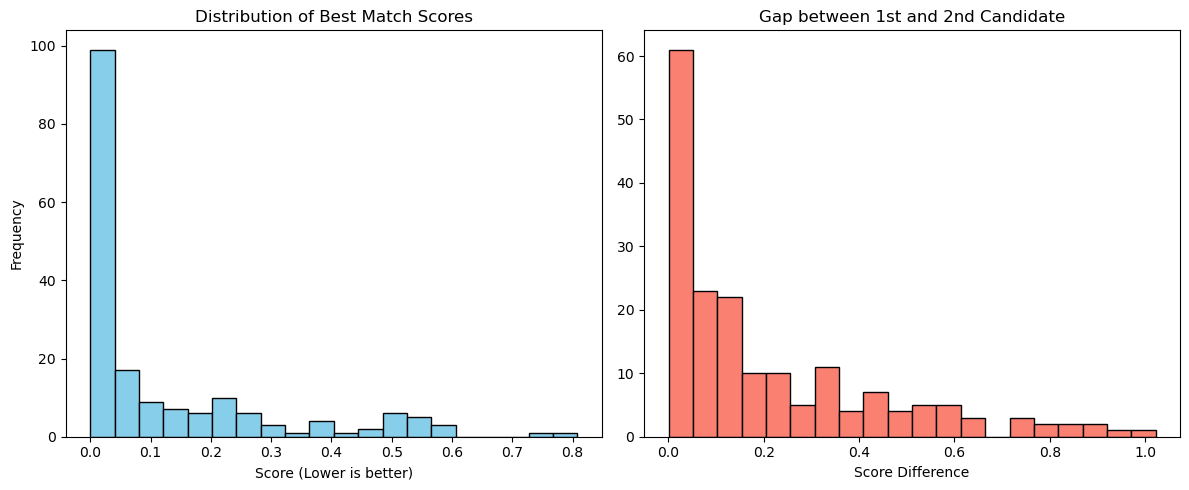

In [ ]:
import matplotlib.pyplot as plt

all_scores = []
score_diffs = []

df_sorted = df_track_for_test.sort_values(['original_segment_id', 'match_score_simple'])
for segment_id, candidates_df in df_track_for_test.groupby('original_segment_id'):
    
    best_score = candidates_df.iloc[0]['match_score_simple']
    all_scores.append(best_score)
    
    if len(candidates_df) > 1:
        diff = candidates_df.iloc[1]['match_score_simple'] - best_score
        score_diffs.append(diff)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(all_scores, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Best Match Scores")
plt.xlabel("Score (Lower is better)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(score_diffs, bins=20, color='salmon', edgecolor='black')
plt.title("Gap between 1st and 2nd Candidate")
plt.xlabel("Score Difference")

plt.tight_layout()
plt.show()

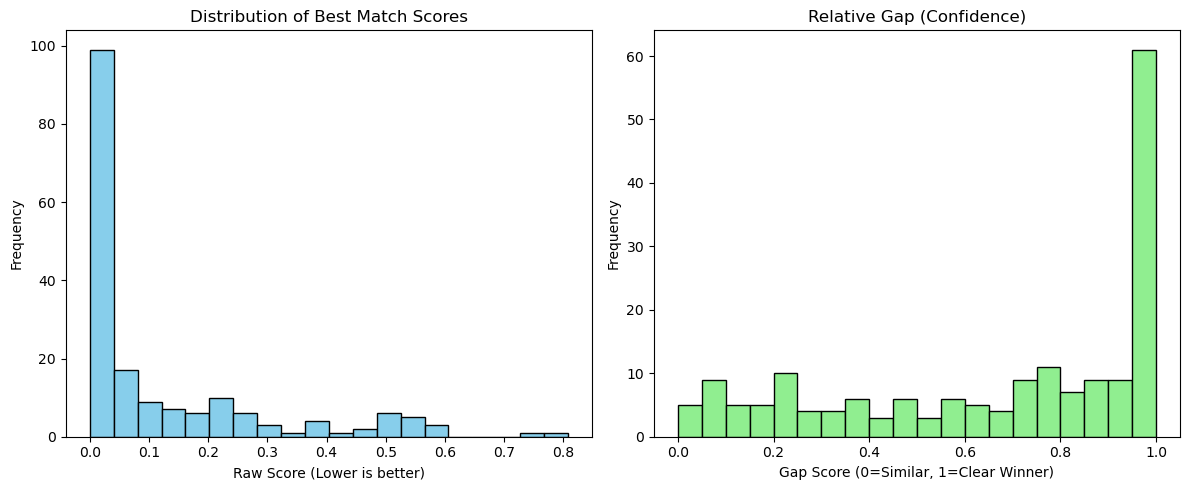

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Analysis: Distribution of scores
all_scores = []
relative_gaps = [] 

for segment_id, candidates_df in df_track_for_test.groupby('original_segment_id'):
    
    # 1. Collect the best score
    best_score = candidates_df.iloc[0]['match_score_simple']
    all_scores.append(best_score)
    
    # 2. Calculate the RELATIVE GAP
    if len(candidates_df) > 1:
        second_score = candidates_df.iloc[1]['match_score_simple']
      
        # Formula: What % error does the 2nd have compared to the 1st?
        # A value close to 1 means the 1st is MUCH better (e.g., 0.001 vs 0.05)
        # A value close to 0 means they are similar (e.g., 0.8 vs 0.81)
        rel_diff = (second_score - best_score) / second_score
        relative_gaps.append(rel_diff)

plt.figure(figsize=(12, 5))

# Plot 1 
plt.subplot(1, 2, 1)
plt.hist(all_scores, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Best Match Scores")
plt.xlabel("Raw Score (Lower is better)")
plt.ylabel("Frequency")

# Plot 2 
plt.subplot(1, 2, 2)

plt.hist(relative_gaps, bins=20, range=(0, 1), color='lightgreen', edgecolor='black')
plt.title("Relative Gap (Confidence)")
plt.xlabel("Gap Score (0=Similar, 1=Clear Winner)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

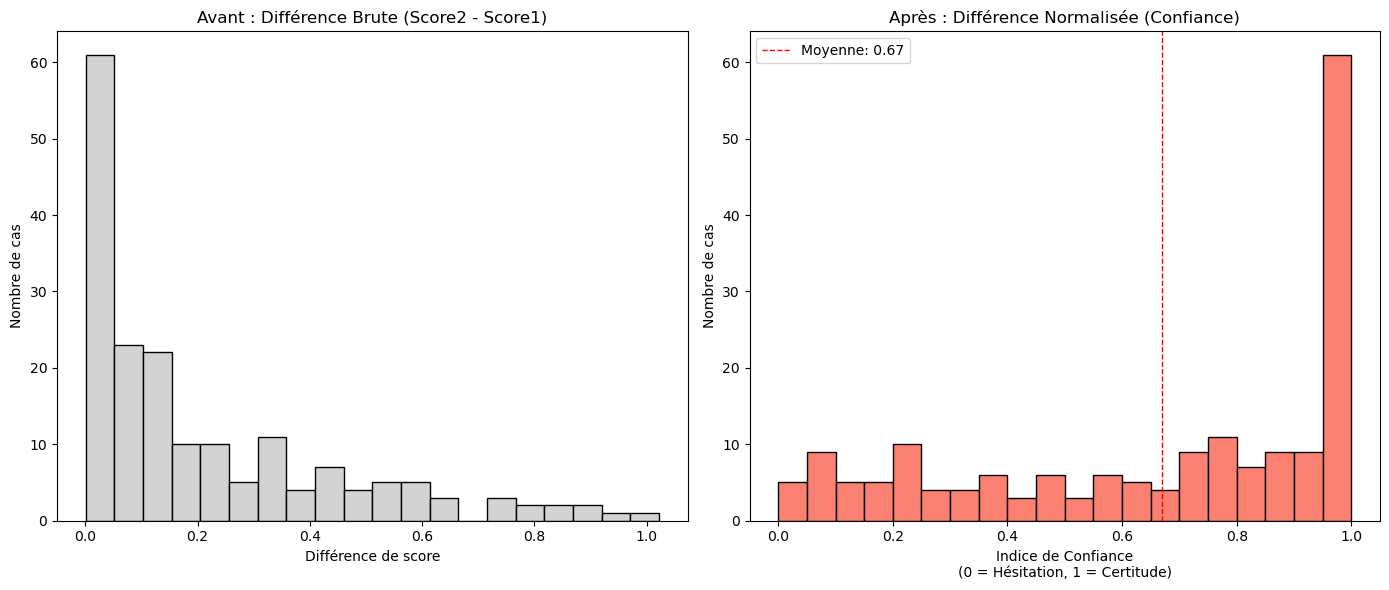

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

normalized_diffs = []
raw_diffs = []


for segment_id, candidates_df in df_track_for_test.groupby('original_segment_id'):
    
    if len(candidates_df) > 1:
        
        best_score = candidates_df.iloc[0]['match_score_simple']
        second_score = candidates_df.iloc[1]['match_score_simple']
        
        diff = second_score - best_score
        raw_diffs.append(diff)
        
        # Formule : (Second - Best) / Second
        
        if second_score > 0:
            norm_diff = (second_score - best_score) / second_score
            normalized_diffs.append(norm_diff)


plt.figure(figsize=(14, 6))

# Graph : simple diff
plt.subplot(1, 2, 1)
plt.hist(raw_diffs, bins=20, color='lightgray', edgecolor='black')
plt.title("Avant : Différence Brute (Score2 - Score1)")
plt.xlabel("Différence de score")
plt.ylabel("Nombre de cas")

# Graph 2 : diff normalise
plt.subplot(1, 2, 2)
plt.hist(normalized_diffs, bins=20, range=(0, 1), color='salmon', edgecolor='black')
plt.title("Après : Différence Normalisée (Confiance)")
plt.xlabel("Indice de Confiance\n(0 = Hésitation, 1 = Certitude)")
plt.ylabel("Nombre de cas")

# Add line to see the avg
plt.axvline(np.mean(normalized_diffs), color='red', linestyle='dashed', linewidth=1, label=f'Moyenne: {np.mean(normalized_diffs):.2f}')
plt.legend()

plt.tight_layout()
plt.show()